# AI Estimation of Air Pollution Percentage in Kyrgyzstan
## Transfer Learning Comparative Study (Regression)

# Stage 1 — Preparation
### Step 1.1: Reproducibility

In [ ]:
import tensorflow as tf
import numpy as np
import random
import os
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Step 1.2: GPU Check

In [ ]:
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Stage 2 — Data Loading
### Step 2.1: Connect Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2.2: Load Metadata

In [ ]:
CSV_PATH = "/content/drive/MyDrive/metadata.csv"
BASE_DIR = "/content/drive/MyDrive/project_dataset"

df = pd.read_csv(CSV_PATH)
df["Image"] = df["Image"].astype(str).str.strip()

# Step 2.3: Resolve Paths

In [ ]:
image_index = {}

for split in ["train", "val", "test"]:
    split_dir = os.path.join(BASE_DIR, split)
    for root, _, files in os.walk(split_dir):
        for f in files:
            image_index[f.lower()] = os.path.join(root, f)

def resolve_path(name):
    return image_index.get(name.lower(), "")

df["image_path"] = df["Image"].apply(resolve_path)
df = df[df["image_path"] != ""].reset_index(drop=True)

# Step 2.4: Train / Val / Test

In [ ]:
train_df = df[df["image_path"].str.contains("/train/")].reset_index(drop=True)
val_df   = df[df["image_path"].str.contains("/val/")].reset_index(drop=True)
test_df  = df[df["image_path"].str.contains("/test/")].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 710
Val: 151
Test: 153


# Stage 3 — Normalization

In [ ]:
aqi_mean = train_df["AQI"].mean()
aqi_std  = train_df["AQI"].std() + 1e-8

# Stage 4 — Dataset Pipeline

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label
def create_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values
    aqi = ((dataframe["AQI"] - aqi_mean) / aqi_std).astype("float32").values
    pm25 = dataframe["PM2.5"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, pm25, aqi))

    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=SEED)

    def load_data(path, pm_value, target):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = preprocess_input(img)

        pm_value = tf.expand_dims(pm_value, -1)

        return (img, pm_value), target

    ds = ds.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

# Stage 5 — Model Definitions
### Model 1 — VGG16 (Image Only)

In [ ]:
def build_vgg_hybrid():

    from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate
    from tensorflow.keras.models import Model
    from tensorflow.keras.applications import VGG16

    image_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    pm_input = Input(shape=(1,))

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_tensor=image_input,
        name="vgg_base"   # ← ВАЖНО
    )

    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)

    combined = Concatenate()([x, pm_input])

    x = Dense(128, activation="relu")(combined)
    output = Dense(1, activation="linear")(x)

    model = Model(inputs=[image_input, pm_input], outputs=output)

    return model

# Model 2 — EfficientNet




In [ ]:
def build_efficientnet_hybrid():

    from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Concatenate
    from tensorflow.keras.models import Model
    from tensorflow.keras.applications import EfficientNetB0

    image_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    pm_input = Input(shape=(1,))

    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_tensor=image_input,
        name="eff_base"   # ← ВАЖНО
    )

    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)

    combined = Concatenate()([x, pm_input])

    x = Dense(128, activation="relu")(combined)
    output = Dense(1, activation="linear")(x)

    model = Model(inputs=[image_input, pm_input], outputs=output)

    return model

# Stage 6 — Training Function

In [ ]:
def train_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.Huber(),
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    return history

# Stage 7 — Train Both Models

In [ ]:
vgg_model = build_vgg()
vgg_history = train_model(vgg_model)

eff_model = build_efficientnet()
eff_history = train_model(eff_model)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - loss: 1.6125 - mae: 2.0580 - rmse: 2.7514 - val_loss: 1.8117 - val_mae: 2.2562 - val_rmse: 3.0047 - learning_rate: 1.0000e-04
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - loss: 1.1093 - mae: 1.5390 - rmse: 2.0132 - val_loss: 1.6277 - val_mae: 2.0782 - val_rmse: 2.6420 - learning_rate: 1.0000e-04
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - loss: 0.8784 - mae: 1.2831 - rmse: 1.6917 - val_loss: 1.5057 - val_mae: 1.9558 - val_rmse: 2.4591 - learning_rate: 1.0000e-04
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 0.7208 - mae: 1.1124 - rmse: 1.4716 - val_loss: 1.4225 - val_mae: 1.8688 - val_rmse: 2.3617 - learning_rate: 1.0000e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: 0.6295 - mae: 1.0089 - rmse: 1.3802 - val_loss: 1.4238 - val_mae: 1.8677 - val_rmse: 2.3047 - learning_rate: 1.0000e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 0.4933 - mae: 0.8526 - rmse: 1.1557 - val_loss: 1.36

# Stage 7.1 — Fine-Tuning (Hybrid)
for VGG16 Hybrid

In [ ]:
vgg_base = vgg_model.get_layer("vgg16")

vgg_base.trainable = True

for layer in vgg_base.layers[:-4]:
    layer.trainable = False

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

vgg_finetune_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)


Epoch 1/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - loss: 0.2941 - mae: 0.6245 - rmse: 0.8268 - val_loss: 1.1259 - val_mae: 1.5673 - val_rmse: 1.9289
Epoch 2/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - loss: 0.1972 - mae: 0.4897 - rmse: 0.6610 - val_loss: 1.1128 - val_mae: 1.5514 - val_rmse: 1.9116
Epoch 3/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 0.1061 - mae: 0.3474 - rmse: 0.4689 - val_loss: 1.0657 - val_mae: 1.5040 - val_rmse: 1.8598
Epoch 4/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - loss: 0.0691 - mae: 0.2701 - rmse: 0.3781 - val_loss: 1.0195 - val_mae: 1.4459 - val_rmse: 1.8364
Epoch 5/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 0.0466 - mae: 0.2211 - rmse: 0.3069 - val_loss: 1.0383 - val_mae: 1.4685 - val_rmse: 1.8438
Epoch 6/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - loss: 0.0248 - mae: 0.1593 - rmse: 0.2237 - val_loss: 1.0234 - val_mae: 1.4517 - val_rmse: 1.8313
Epoch 7/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - loss: 0.0172 - mae: 0.1162 - rmse: 0.1921 - val_loss: 1

For EfficientNet Hybrid

In [ ]:
eff_base = eff_model.get_layer("efficientnetb0")

eff_base.trainable = True

for layer in eff_base.layers[:-4]:
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

eff_finetune_history = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)



Epoch 1/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - loss: 0.2677 - mae: 0.6024 - rmse: 0.7546 - val_loss: 0.6740 - val_mae: 1.0750 - val_rmse: 1.3688
Epoch 2/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - loss: 0.2893 - mae: 0.6222 - rmse: 0.7970 - val_loss: 0.6728 - val_mae: 1.0720 - val_rmse: 1.3665
Epoch 3/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - loss: 0.2781 - mae: 0.6205 - rmse: 0.7850 - val_loss: 0.6730 - val_mae: 1.0730 - val_rmse: 1.3666
Epoch 4/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - loss: 0.2582 - mae: 0.5792 - rmse: 0.7499 - val_loss: 0.6727 - val_mae: 1.0718 - val_rmse: 1.3662
Epoch 5/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 0.2380 - mae: 0.5610 - rmse: 0.7138 - val_loss: 0.6747 - val_mae: 1.0720 - val_rmse: 1.3677
Epoch 6/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 0.2454 - mae: 0.5724 - rmse: 0.7266 - val_loss: 0.6754 - val_mae: 1.0721 - val_rmse: 1.3684
Epoch 7/8
23/23 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - loss: 0.2417 - mae: 0.5602 - rmse: 0.7252 - val_loss: 0

# Stage 8 — Evaluation Function

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0).flatten()

        preds = preds * aqi_std + aqi_mean
        labels = labels.numpy() * aqi_std + aqi_mean

        y_true.extend(labels)
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2, y_true, y_pred

# Stage 9 — Final Testing (Official Test Evaluation)

In [ ]:
vgg_rmse, vgg_mae, vgg_r2, y_true, y_pred_vgg = evaluate_model(vgg_model)
eff_rmse, eff_mae, eff_r2, _, y_pred_eff = evaluate_model(eff_model)

print("VGG16 RMSE:", vgg_rmse)
print("EfficientNet RMSE:", eff_rmse)

VGG16 RMSE: 78.7114853881218
EfficientNet RMSE: 66.49041105702605


# Step 9.1: Evaluate VGG16 on Test Set

In [ ]:
vgg_rmse, vgg_mae, vgg_r2, y_true, y_pred_vgg = evaluate_model(vgg_model)

print("\n===== VGG16 TEST RESULTS =====")
print(f"RMSE: {vgg_rmse:.2f}")
print(f"MAE: {vgg_mae:.2f}")
print(f"R²: {vgg_r2:.4f}")


===== VGG16 TEST RESULTS =====
RMSE: 78.71
MAE: 58.78
R²: -0.7940


# Step 9.2: Evaluate EfficientNet on Test Set

In [ ]:
eff_rmse, eff_mae, eff_r2, _, y_pred_eff = evaluate_model(eff_model)

print("\n===== EfficientNet TEST RESULTS =====")
print(f"RMSE: {eff_rmse:.2f}")
print(f"MAE: {eff_mae:.2f}")
print(f"R²: {eff_r2:.4f}")


===== EfficientNet TEST RESULTS =====
RMSE: 66.49
MAE: 49.00
R²: -0.2801


# Step 9.3: Comparison Table


In [ ]:
results = pd.DataFrame({
    "Model": ["VGG16", "EfficientNet"],
    "RMSE": [vgg_rmse, eff_rmse],
    "MAE": [vgg_mae, eff_mae],
    "R²": [vgg_r2, eff_r2]
})

print()
results

,Model,RMSE,MAE,R²
0,VGG16,78.711485,58.780512,-0.793968
1,EfficientNet,66.490411,49.001094,-0.280137


# Stage 10 — Baseline

In [ ]:
baseline_pred = np.full_like(y_true, train_df["AQI"].mean())

baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))
baseline_mae = mean_absolute_error(y_true, baseline_pred)
baseline_r2 = r2_score(y_true, baseline_pred)

# Stage 11 — Graphs
Loss

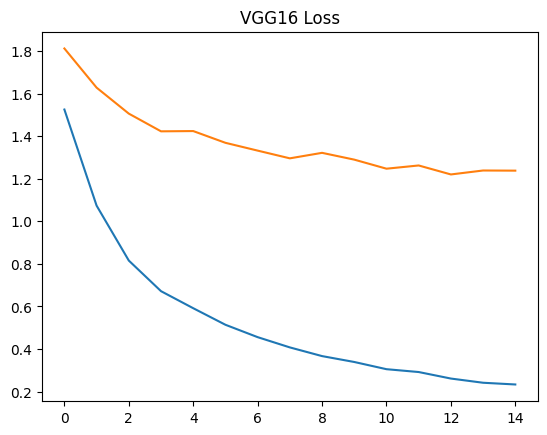

In [ ]:
plt.plot(vgg_history.history["loss"])
plt.plot(vgg_history.history["val_loss"])
plt.title("VGG16 Loss")
plt.show()

RMSE

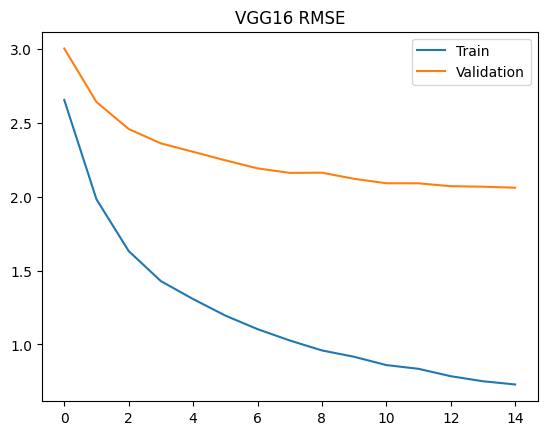

In [ ]:
plt.figure()
plt.plot(vgg_history.history["rmse"])
plt.plot(vgg_history.history["val_rmse"])
plt.title("VGG16 RMSE")
plt.legend(["Train", "Validation"])
plt.show()

true vs pred

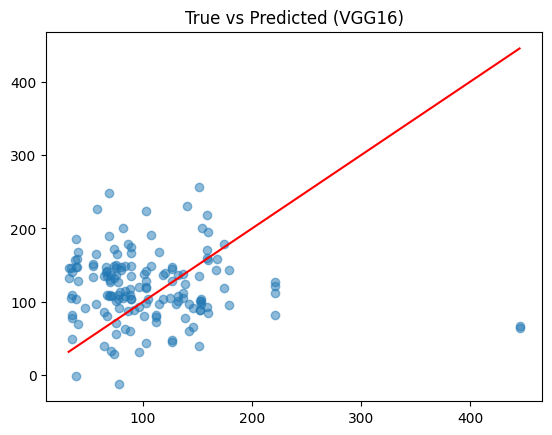

In [ ]:
plt.scatter(y_true, y_pred_vgg, alpha=0.5)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color="red")
plt.title("True vs Predicted (VGG16)")
plt.show()

# Error Distribution

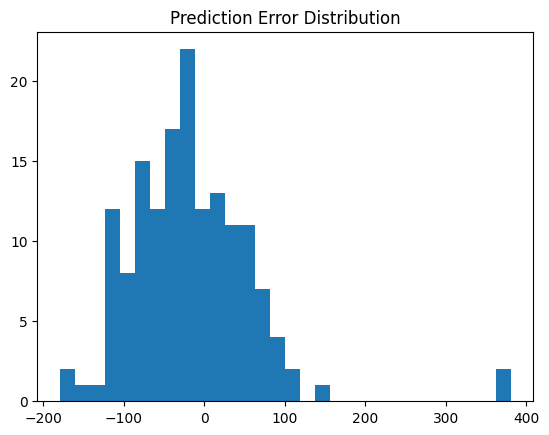

In [ ]:
errors = y_true - y_pred_vgg
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.show()